7. Explainability with SHAP -with new added features

c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13072\1207136854.py:56: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


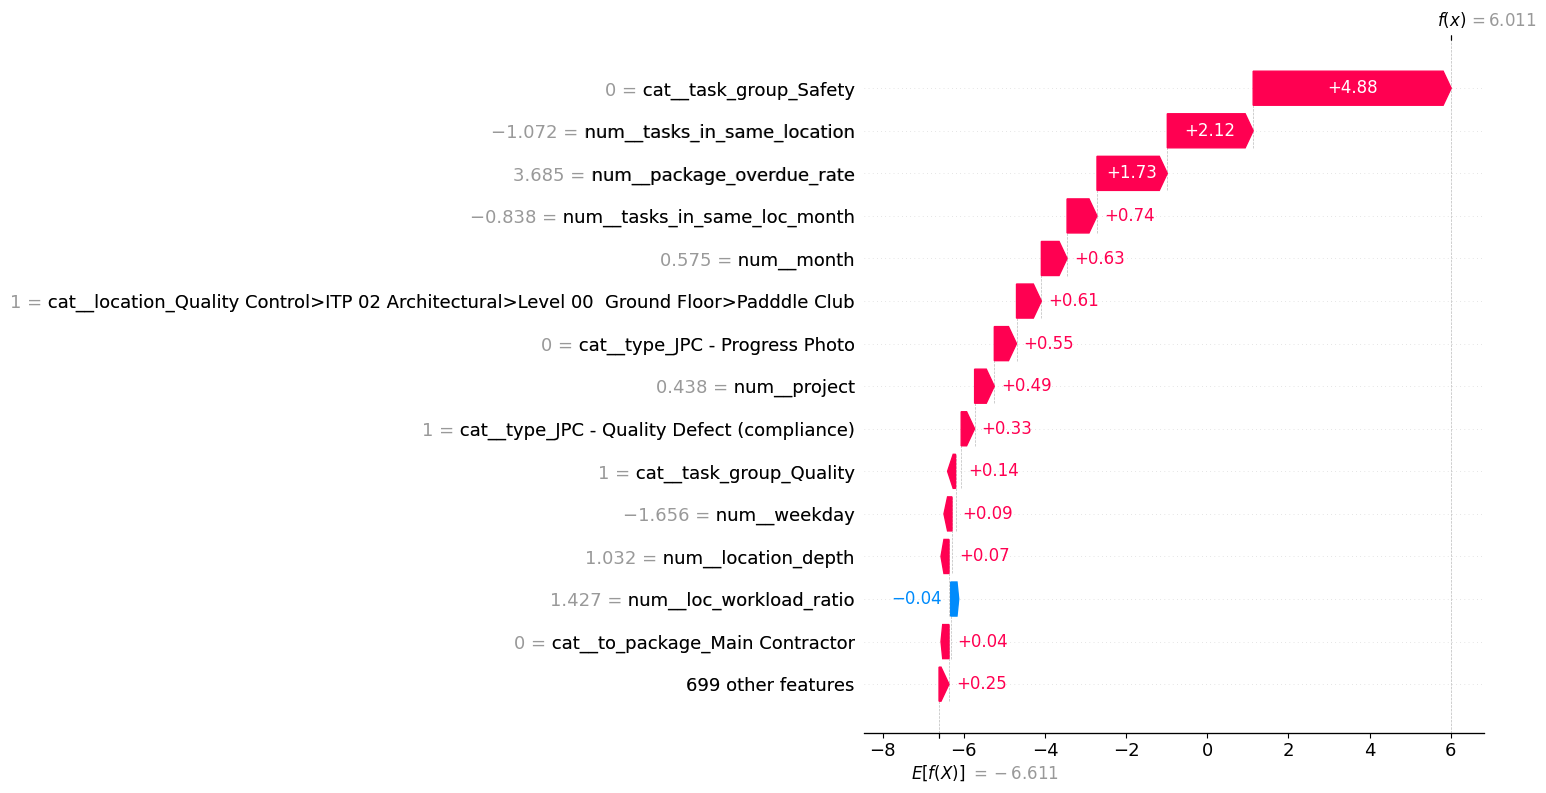

In [2]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

import joblib, shap, matplotlib.pyplot as plt, pandas as pd, numpy as np

MODEL, HOLD, OUT = ROOT/'models/overdue_risk_new_features_added_model.joblib', ROOT/'models/evaluation_new_features_added_holdout.joblib', ROOT/'figures/shap'
OUT.mkdir(parents=True, exist_ok=True)

pipe, hold = joblib.load(MODEL), joblib.load(HOLD)

X = hold['X_test'].sample(n=min(500, len(hold['X_test'])), random_state=42)
pre = pipe.named_steps['preprocessor']
Xt = pre.transform(X)
Xt = Xt.toarray() if hasattr(Xt, 'toarray') else np.asarray(Xt, dtype=float)
names = pre.get_feature_names_out()

# SHAP
model = pipe.named_steps['model']
explainer = shap.TreeExplainer(model)
values = explainer.shap_values(Xt)


if isinstance(values, list):
    positive_values = values[1]  #  Random Forest
elif np.ndim(values) == 3:
    positive_values = values[..., 1]
else:
    positive_values = values  #  LightGBM/XGBoost

# 1. (Global Summary Plot)
plt.figure()
shap.summary_plot(positive_values, Xt, feature_names=names, show=False)
plt.tight_layout()
plt.savefig(OUT/'global_feature_importance_new_features_added.png', dpi=160, bbox_inches='tight')
plt.close()

# 2.  IndexError
base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)) and len(np.atleast_1d(base_val)) > 1:
    base_val = base_val[1]
elif isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[0]

# 3.  (Waterfall Plot)
idx = int(np.argmax(pipe.predict_proba(X)[:, 1]))

plt.figure()
explanation = shap.Explanation(
    values=positive_values[idx],
    base_values=base_val,
    data=Xt[idx],
    feature_names=names
)
shap.plots.waterfall(explanation, max_display=15, show=False)
plt.tight_layout()
plt.savefig(OUT/'individual_high_risk_explanation_new_features_added.png', dpi=160, bbox_inches='tight')
plt.show()
